# Model Development and Evaluation

## Objective

Train and evaluate multiple classification models for Heart Disease Prediction using a reproducible workflow.


## 1. Import Libraries

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import matplotlib.pyplot as plt


## 2. Load Dataset

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "heart.csv"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 3. Preprocessing

In [3]:
df["target"] = (df["num"] > 0).astype(int)
df.drop(columns=["num"], inplace=True)

imputer = SimpleImputer(strategy="median")
df[["ca","thal"]] = imputer.fit_transform(df[["ca","thal"]])

X = df.drop(columns=["target"])
y = df["target"]

continuous = ["age","trestbps","chol","thalach","oldpeak"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

scaler = StandardScaler()
X_train[continuous] = scaler.fit_transform(X_train[continuous])
X_test[continuous] = scaler.transform(X_test[continuous])

print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


## 4. Logistic Regression

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61

Accuracy : 0.8688524590163934
Precision: 0.8125
Recall   : 0.9285714285714286
F1 Score : 0.8666666666666667
ROC AUC  : 0.9512987012987013


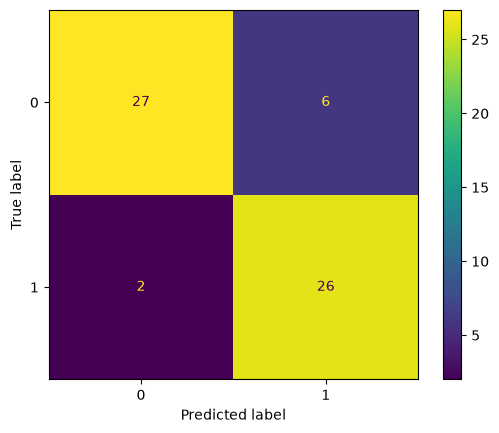

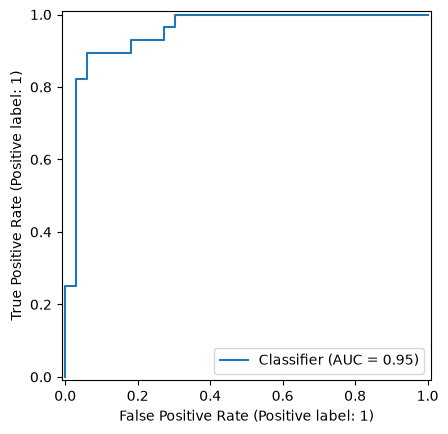

D:\WILP\Semester 3\MLOPs\Heart_Disease_MLOps\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\WILP\Semester 3\MLOPs\Heart_Disease_MLOps\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-le

CV Accuracy: 0.8216939890710382


In [4]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)
prob_lr = lr.predict_proba(X_test)[:,1]

print(classification_report(y_test,pred_lr))
print("Accuracy :",accuracy_score(y_test,pred_lr))
print("Precision:",precision_score(y_test,pred_lr))
print("Recall   :",recall_score(y_test,pred_lr))
print("F1 Score :",f1_score(y_test,pred_lr))
print("ROC AUC  :",roc_auc_score(y_test,prob_lr))

ConfusionMatrixDisplay.from_predictions(y_test,pred_lr)
plt.show()

RocCurveDisplay.from_predictions(y_test,prob_lr)
plt.show()

cv_lr = cross_val_score(lr,X,y,cv=5,scoring="accuracy")
print("CV Accuracy:",cv_lr.mean())

## 5. Random Forest

Best Parameters: {'max_depth': 5, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61

Accuracy : 0.9016393442622951
Precision: 0.8666666666666667
Recall   : 0.9285714285714286
F1 Score : 0.896551724137931
ROC AUC  : 0.9567099567099567


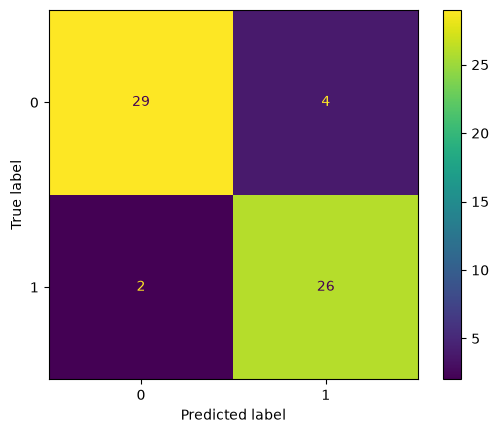

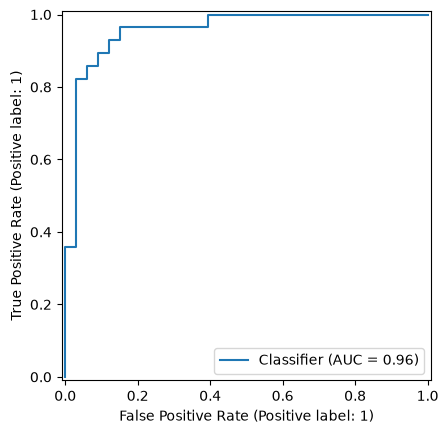

CV Accuracy: 0.8215300546448088


In [5]:
params = {
    "n_estimators":[100,200],
    "max_depth":[None,5,10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train,y_train)

rf = grid.best_estimator_

pred_rf = rf.predict(X_test)
prob_rf = rf.predict_proba(X_test)[:,1]

print("Best Parameters:",grid.best_params_)
print(classification_report(y_test,pred_rf))
print("Accuracy :",accuracy_score(y_test,pred_rf))
print("Precision:",precision_score(y_test,pred_rf))
print("Recall   :",recall_score(y_test,pred_rf))
print("F1 Score :",f1_score(y_test,pred_rf))
print("ROC AUC  :",roc_auc_score(y_test,prob_rf))

ConfusionMatrixDisplay.from_predictions(y_test,pred_rf)
plt.show()

RocCurveDisplay.from_predictions(y_test,prob_rf)
plt.show()

cv_rf = cross_val_score(rf,X,y,cv=5,scoring="accuracy")
print("CV Accuracy:",cv_rf.mean())

## 6. Model Comparison & Save Best Model

In [6]:
results = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest"],
    "Accuracy":[accuracy_score(y_test,pred_lr),accuracy_score(y_test,pred_rf)],
    "Precision":[precision_score(y_test,pred_lr),precision_score(y_test,pred_rf)],
    "Recall":[recall_score(y_test,pred_lr),recall_score(y_test,pred_rf)],
    "F1 Score":[f1_score(y_test,pred_lr),f1_score(y_test,pred_rf)],
    "ROC AUC":[roc_auc_score(y_test,prob_lr),roc_auc_score(y_test,prob_rf)]
})

display(results)

best_model = rf if accuracy_score(y_test,pred_rf) >= accuracy_score(y_test,pred_lr) else lr
joblib.dump(best_model, MODELS_DIR / "best_model.pkl")
joblib.dump(scaler, MODELS_DIR / "scaler.pkl")

print("Best model saved successfully.")


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.951299
1,Random Forest,0.901639,0.866667,0.928571,0.896552,0.956710


Best model saved successfully.
